# XGBoost cluster classifier + SHAP interpretation

**Goal.** Each phosphosite has been assigned to a *dynamic cluster* based on its EGF/INS/EGFnINS
temporal response. Here we ask: **can a site's metadata predict which cluster it lands in, and which
metadata matter most?** We train small XGBoost multi-class classifiers and use **SHAP** to attribute
the prediction to individual features.

**Two engineered feature families** (built in `src/xgboost_model.py`):

| Family | What it captures | Role |
|--------|------------------|------|
| **A — biological metadata** | predicted kinase, residue, ERK motif, functional score, localization, peptide quality, curated-annotation flags | **independent predictor** — "does intrinsic site biology explain the cluster?" |
| **B — temporal-shape descriptors** | per-condition peak / AUC / slopes / amplitude / transient score + cross-condition synergy, summarised from the FC profiles | **descriptive** for the adaptive target (see below) |

**Leakage note (important).** The `KMeans_adaptive_cluster_WT_EGF_*` labels — despite the name — were
computed from **all three conditions jointly** (EGF + INS + EGFnINS). So the temporal-shape descriptors
(family B) *reconstruct the clustering input* and act as a **characterisation of cluster geometry**, not
an independent test. Family A is always independent. We therefore run **three models** — A only, B only,
A+B combined — and read SHAP separately, keeping "what shape defines a cluster" apart from "what biology
explains a cluster". (For the EGF-only `KMeans_11_*` target, the INS/EGFnINS descriptors *would* be
genuinely non-leaky — a crosstalk test — hence the `TARGET_COL` parameter.)

> **Scope:** WT hTERT-HME1 (hme1_2) dataset. This is the WT-side foundation for later transferring
> cluster labels to the mutant datasets.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost, shap
from src.xgboost_model import (
    build_bio_features,
    build_temporal_features,
    get_target,
    run_feature_group,
    cross_validate_xgb,
    plot_confusion,
    shap_explain,
    plot_shap_global,
    plot_shap_per_class,
)
from src.column_spec import ColumnSpec

print("xgboost", xgboost.__version__, "| shap", shap.__version__)

xgboost 2.0.3 | shap 0.49.1


/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Parameters

In [2]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the run
# ════════════════════════════════════════════════════════════
DATA_PATH   = "../../notebooks/03_clustering/Data_clustered/20260715_hTERT_HEM1_2_processed_phPlus_clustered_kinasepred.tsv"

# Target cluster-label column to predict (any of the 6 label columns can be swapped in).
# Default = adaptive on FC (all-3-condition clustering; 11 clusters).
TARGET_COL  = "KMeans_adaptive_cluster_WT_EGF_log2_FC"

# Temporal-descriptor feature settings (family B)
TEMPORAL_DATA_TYPE = "log2:FC"                       # transform space to summarise
CONDITIONS         = ("_EGF_", "_INS_", "_EGFnINS_") # conditions to summarise

# Model / evaluation
TEST_SIZE     = 0.2
RANDOM_STATE  = 0
TOP_K_KINASES = 25        # one-hot the top-K rank-1 predicted kinases (+ 'other')
N_SPLITS      = 5         # cross-validation folds
SHAP_SAMPLES  = 2000      # rows explained by SHAP (sampled for speed)

# Save fitted models + comparison table to Results/?
SAVE_ARTIFACTS = False
RESULTS_DIR    = "Results"


## 1. Load data

In [3]:
df = pd.read_csv(DATA_PATH, sep="\t", low_memory=False,)
print("rows x cols:", df.shape)
print("target:", TARGET_COL, "->", sorted(df[TARGET_COL].unique()))

rows x cols: (8723, 481)
target: KMeans_adaptive_cluster_WT_EGF_log2_FC -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 2. Build the two feature families

`build_bio_features` (A) encodes intrinsic metadata; `build_temporal_features` (B) summarises the FC
temporal profiles into shape descriptors. We assemble `X_combined = A + B` for the third model. A quick
check confirms **no raw temporal columns leak into the feature matrices**.

In [4]:
X_bio      = build_bio_features(df, top_k_kinases=TOP_K_KINASES,)
X_temporal = build_temporal_features(df,
                                     data_type=TEMPORAL_DATA_TYPE,
                                     conditions=CONDITIONS,)
X_combined = pd.concat([X_bio, X_temporal], axis=1,)

print("bio      :", X_bio.shape)
print("temporal :", X_temporal.shape)
print("combined :", X_combined.shape)

# leakage guard: no raw {CellLine}_{datatype}_... data columns should appear as features
leaky = [c for c in X_combined.columns if c.startswith(("WT_raw:", "WT_log2:"))]
assert not leaky, f"raw data columns leaked into features: {leaky}"
assert TARGET_COL not in X_combined.columns
print("\nleakage guard passed (no raw data / label columns in features)")

print("\nbio feature list:\n", list(X_bio.columns))
print("\ntemporal feature list:\n", list(X_temporal.columns))

bio      : (8723, 47)
temporal : (8723, 36)
combined : (8723, 83)

leakage guard passed (no raw data / label columns in features)

bio feature list:
 ['functional_score', 'MaxPepProb', 'protein_length', 'nrPeptides', 'nr_tryptic_peptides', 'NumPhos', 'LocalizedNumPhos', 'n:reps', 'predicted_kinase_1_prob', 'predicted_kinase_2_prob', 'predicted_kinase_3_prob', 'predicted_kinase_4_prob', 'predicted_kinase_5_prob', 'peptide_length', 'residue_S', 'residue_T', 'residue_Y', 'erk_motif_any', 'kin1_CDC7', 'kin1_KIS', 'kin1_PINK1', 'kin1_ERK2', 'kin1_ERK5', 'kin1_GSK3B', 'kin1_PRP4', 'kin1_ERK7', 'kin1_JNK1', 'kin1_CDK2', 'kin1_AURA', 'kin1_CHK1', 'kin1_FAM20C', 'kin1_CDK16', 'kin1_PIM3', 'kin1_MTOR', 'kin1_MAPKAPK2', 'kin1_PDHK4', 'kin1_CAMK2D', 'kin1_NLK', 'kin1_RAF1', 'kin1_YANK2', 'kin1_JNK3', 'kin1_MASTL', 'kin1_DNAPK', 'kin1_other', 'has_ON_FUNCTION', 'has_ON_PROCESS', 'has_ON_PROT_INTERACT']

temporal feature list:
 ['EGF_peak_value', 'EGF_peak_time', 'EGF_trough_value', 'EGF_amplitude',

In [5]:
# Missingness of the kinase-derived features (NaN only for non-single-localized sites; XGBoost handles it)
na_frac = X_combined.isna().mean().sort_values(ascending=False,)
na_frac[na_frac > 0].round(3).to_frame("nan_fraction",)

,nan_fraction
predicted_kinase_5_prob,0.406
predicted_kinase_1_prob,0.406
predicted_kinase_2_prob,0.406
predicted_kinase_3_prob,0.406
predicted_kinase_4_prob,0.406


## 3. Target distribution

Cluster sizes are imbalanced — one cluster dominates, so **macro-F1** (not accuracy) is the honest metric, and we train with balanced sample weights.

11 clusters | majority-class baseline accuracy = 0.617


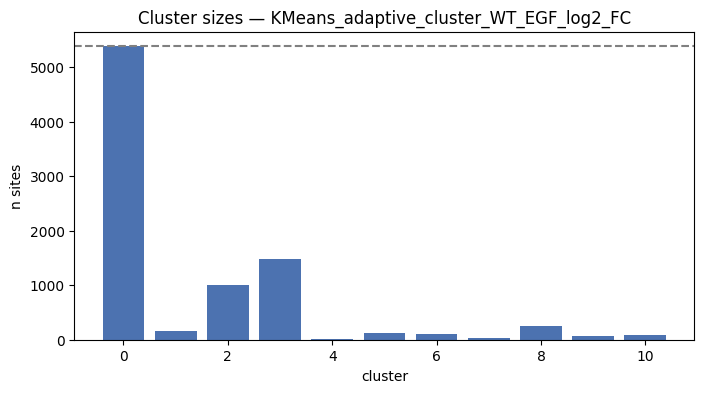

In [6]:
y, classes = get_target(df, TARGET_COL,)
counts = pd.Series(y,).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4),)
ax.bar([classes[i] for i in counts.index], counts.values, color="#4C72B0",)
ax.set_xlabel("cluster"); ax.set_ylabel("n sites"); ax.set_title(f"Cluster sizes — {TARGET_COL}")
majority = counts.max() / counts.sum()
ax.axhline(counts.max(), ls="--", c="grey",)
print(f"{len(classes)} clusters | majority-class baseline accuracy = {majority:.3f}")
plt.show()

## 4. Run and compare the three models

Each feature group gets its own stratified split, balanced-weight XGBoost fit, and evaluation against a
majority-class baseline. **Expected pattern:** temporal-only ≳ combined ≫ bio-only, because the temporal
descriptors reconstruct the clustering input while bio-only tests genuinely independent signal.

In [7]:
results = {}
for name, X in [("bio", X_bio), ("temporal", X_temporal), ("combined", X_combined)]:
    results[name] = run_feature_group(X, y,
                                      name=name,
                                      class_labels=classes,
                                      test_size=TEST_SIZE,
                                      random_state=RANDOM_STATE,)

comparison = pd.DataFrame([
    {"model": r["name"], "n_features": r["n_features"],
     "accuracy": r["accuracy"], "macro_f1": r["macro_f1"],
     "baseline_acc": r["baseline_acc"], "lift_vs_baseline": r["lift"]}
    for r in results.values()
]).set_index("model")
comparison.round(3)

,n_features,accuracy,macro_f1,baseline_acc,lift_vs_baseline
model,,,,,
bio,47,0.449,0.194,0.617,-0.168
temporal,36,0.977,0.924,0.617,0.360
combined,83,0.976,0.908,0.617,0.359


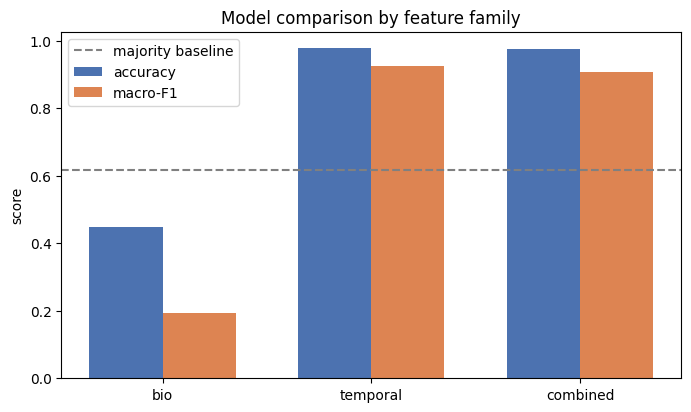

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5),)
idx = np.arange(len(comparison)); w = 0.35
ax.bar(idx - w/2, comparison["accuracy"], w, label="accuracy", color="#4C72B0",)
ax.bar(idx + w/2, comparison["macro_f1"], w, label="macro-F1", color="#DD8452",)
ax.axhline(comparison["baseline_acc"].iloc[0], ls="--", c="grey", label="majority baseline",)
ax.set_xticks(idx); ax.set_xticklabels(comparison.index,)
ax.set_ylabel("score"); ax.set_title("Model comparison by feature family"); ax.legend()
plt.show()

## 5. Per-model evaluation

Classification report + row-normalized confusion matrix for the **bio-only** (independent signal) and **combined** models.


=== bio ===  accuracy=0.449  macro-F1=0.194


,precision,recall,f1-score,support
0,0.712,0.537,0.612,1077.0
1,0.075,0.088,0.081,34.0
2,0.210,0.325,0.255,200.0
3,0.287,0.407,0.337,297.0
4,0.333,0.500,0.400,4.0
5,0.000,0.000,0.000,23.0
6,0.059,0.045,0.051,22.0
7,0.000,0.000,0.000,6.0
8,0.114,0.176,0.138,51.0
9,0.143,0.143,0.143,14.0


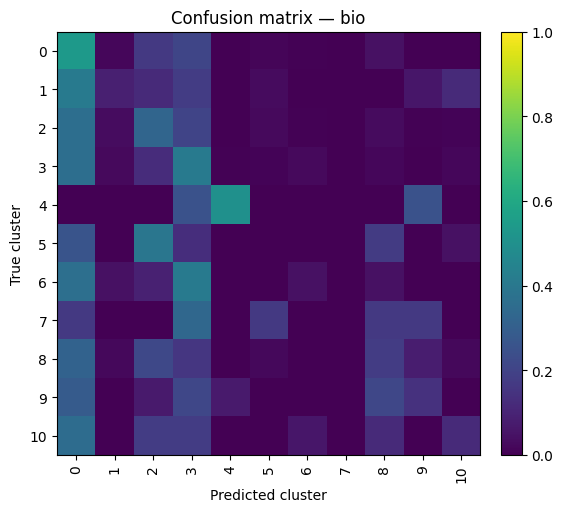


=== combined ===  accuracy=0.976  macro-F1=0.908


,precision,recall,f1-score,support
0,0.993,0.993,0.993,1077.0
1,0.871,0.794,0.831,34.0
2,0.950,0.955,0.953,200.0
3,0.993,0.983,0.988,297.0
4,1.000,1.000,1.000,4.0
5,0.826,0.826,0.826,23.0
6,0.955,0.955,0.955,22.0
7,1.000,0.833,0.909,6.0
8,0.847,0.980,0.909,51.0
9,0.833,0.714,0.769,14.0


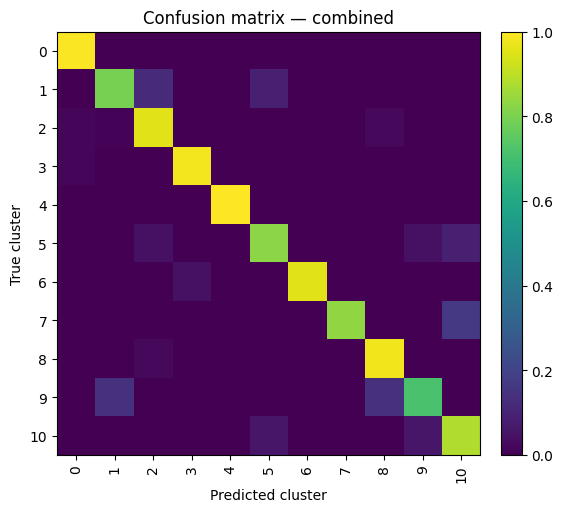

In [9]:
for name in ["bio", "combined"]:
    m = results[name]["metrics"]
    print(f"\n=== {name} ===  accuracy={m['accuracy']:.3f}  macro-F1={m['macro_f1']:.3f}")
    rep = pd.DataFrame(m["report"]).T
    display(rep.loc[[str(c) for c in classes]].round(3))

    _, _, _, y_test = results[name]["split"]
    fig, ax = plt.subplots(figsize=(6.5, 5.5),)
    plot_confusion(y_test, m["y_pred"], class_labels=classes, ax=ax,
                   title=f"Confusion matrix — {name}",)
    plt.show()

## 6. Cross-validation

Stratified K-fold accuracy and macro-F1 (mean ± sd) — confirms the held-out scores are not split-specific.

In [10]:
cv_rows = []
for name, X in [("bio", X_bio), ("temporal", X_temporal), ("combined", X_combined)]:
    cv = cross_validate_xgb(X, y, n_splits=N_SPLITS, random_state=RANDOM_STATE,)
    cv_rows.append({"model": name,
                    "cv_accuracy": f"{cv['accuracy'].mean():.3f} ± {cv['accuracy'].std():.3f}",
                    "cv_macro_f1": f"{cv['macro_f1'].mean():.3f} ± {cv['macro_f1'].std():.3f}"})
pd.DataFrame(cv_rows).set_index("model")

,cv_accuracy,cv_macro_f1
model,,
bio,0.454 ± 0.013,0.208 ± 0.009
temporal,0.976 ± 0.003,0.924 ± 0.024
combined,0.974 ± 0.003,0.919 ± 0.026


## 7. SHAP — biological-metadata model

This is the interpretable result: **which intrinsic features push a site toward which cluster.** The
global bar ranks mean|SHAP| across all classes; the per-cluster beeswarms show direction and magnitude
for individual clusters.

SHAP values: (2000, 47, 11) (samples, features, classes)


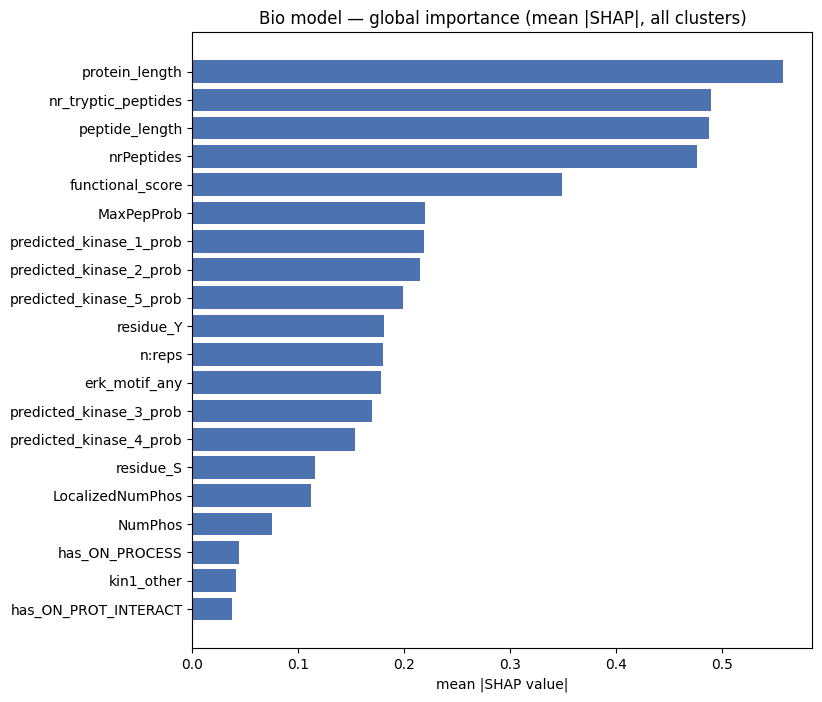

In [11]:
shap_bio, Xs_bio = shap_explain(results["bio"]["model"], X_bio,
                                max_samples=SHAP_SAMPLES, random_state=RANDOM_STATE,)
print("SHAP values:", shap_bio.shape, "(samples, features, classes)")
fig, ax = plt.subplots(figsize=(8, 8),)
plot_shap_global(shap_bio, Xs_bio, max_display=20, ax=ax,
                 title="Bio model — global importance (mean |SHAP|, all clusters)",)
plt.show()

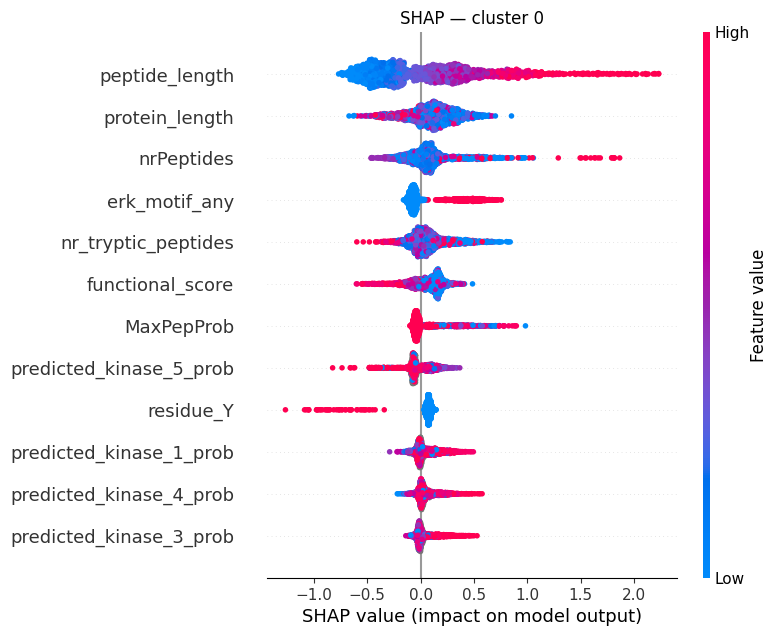

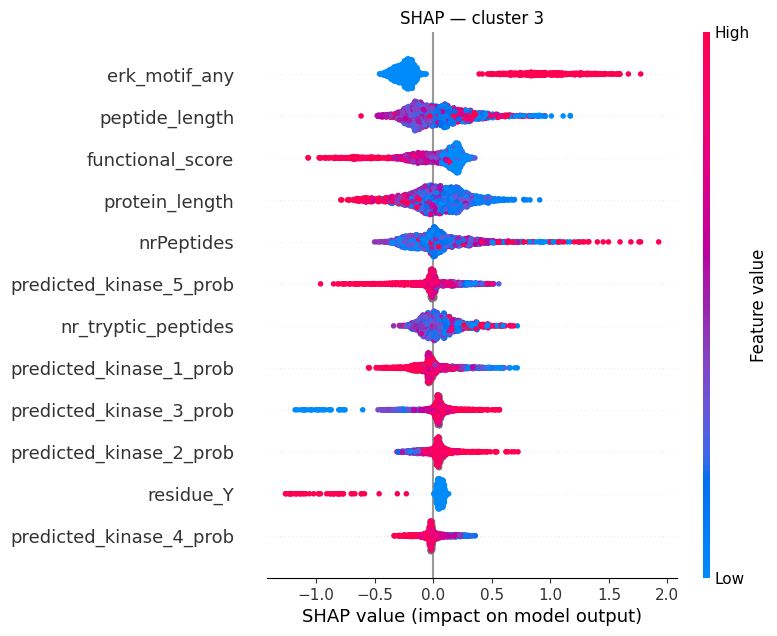

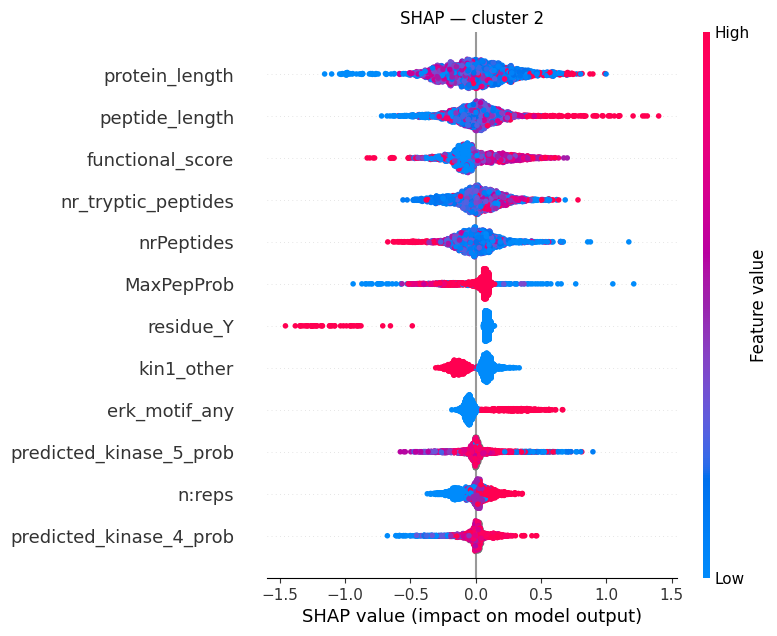

In [12]:
# Per-cluster beeswarm for the largest few clusters
top_clusters = pd.Series(y,).value_counts().index[:3]
for ci in top_clusters:
    plt.figure()
    plot_shap_per_class(shap_bio, Xs_bio, class_index=ci, class_label=classes[ci], max_display=12,)
    plt.show()

## 8. SHAP — temporal-shape model

For the adaptive (all-3-condition) target these features are **descriptive**: they read out *what shape
defines each cluster* (early vs late peak, sustained vs transient, EGF/INS synergy), rather than
revealing independent biology.

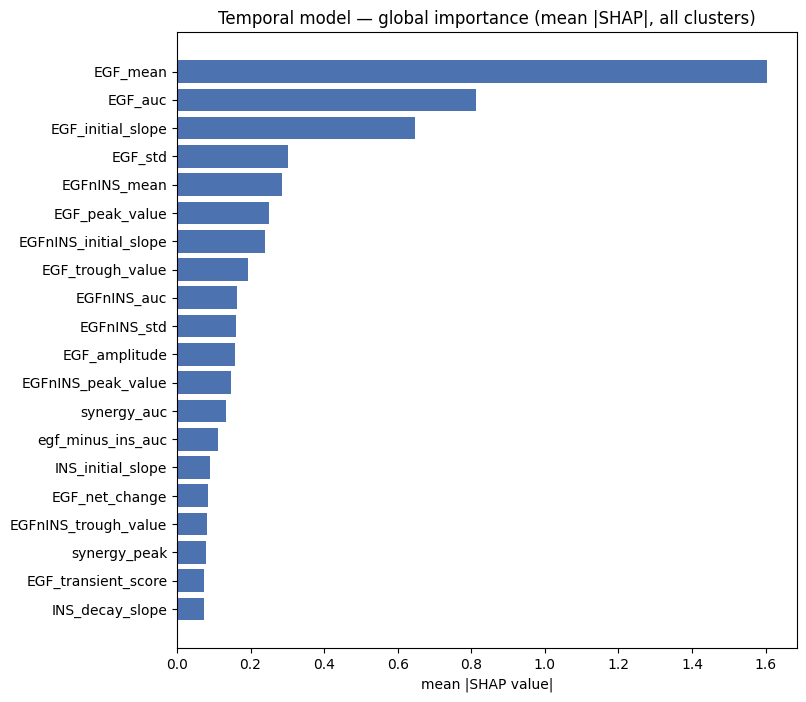

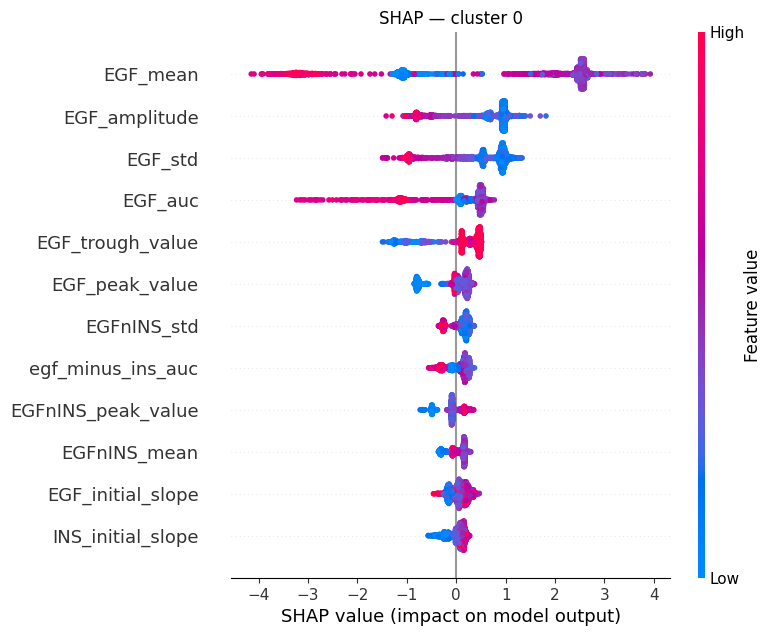

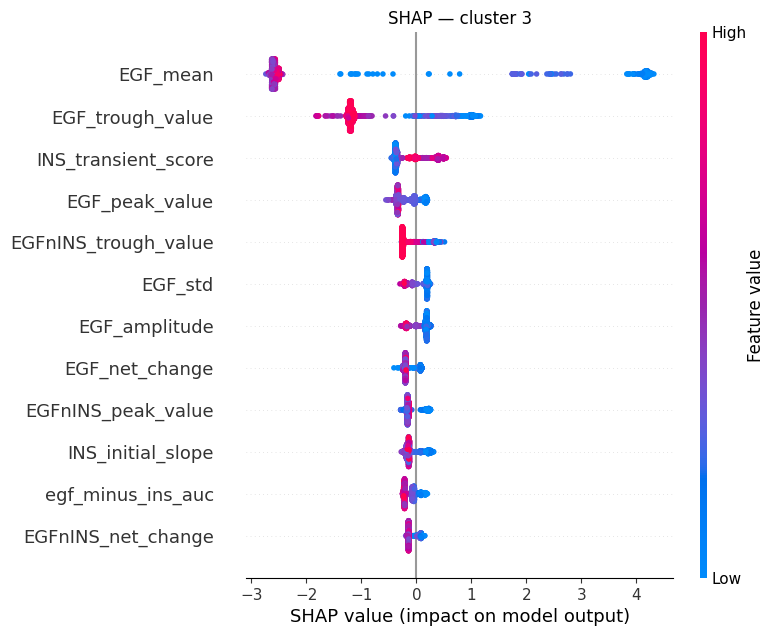

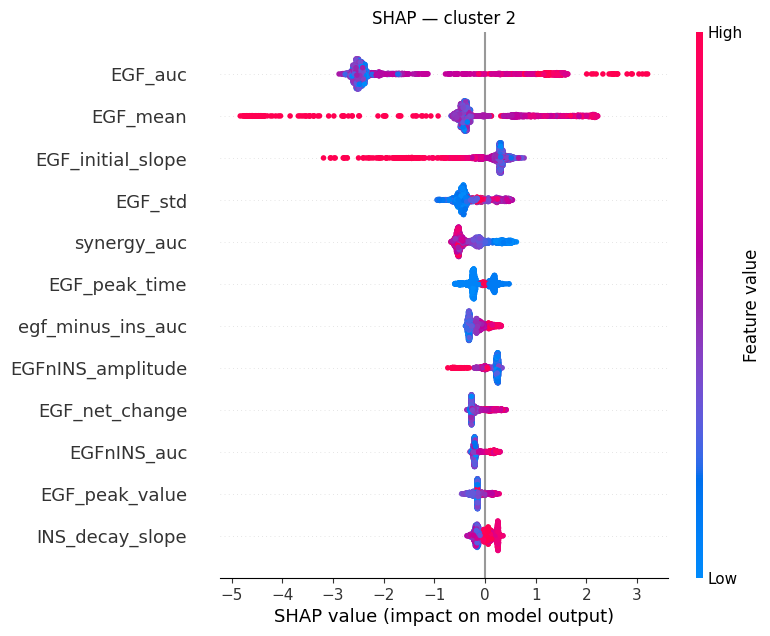

In [13]:
shap_tmp, Xs_tmp = shap_explain(results["temporal"]["model"], X_temporal,
                                max_samples=SHAP_SAMPLES, random_state=RANDOM_STATE,)
fig, ax = plt.subplots(figsize=(8, 8),)
plot_shap_global(shap_tmp, Xs_tmp, max_display=20, ax=ax,
                 title="Temporal model — global importance (mean |SHAP|, all clusters)",)
plt.show()

for ci in top_clusters:
    plt.figure()
    plot_shap_per_class(shap_tmp, Xs_tmp, class_index=ci, class_label=classes[ci], max_display=12,)
    plt.show()

## 9. Interpretation & limitations

**Reading the comparison.** Compare macro-F1 (not accuracy — the classes are imbalanced) across the three
models against the majority baseline:
- **Temporal-only ≈ combined, both high** → confirms the descriptors recover the clustering input (expected;
  the adaptive clustering used all three conditions). SHAP on this model *characterises* each cluster's shape.
- **Bio-only** measures how much of the dynamic cluster is explained by *intrinsic site biology*. Whatever
  lift it shows over the baseline is the genuinely interesting signal; the bio SHAP plots name the drivers
  (e.g. predicted kinase, ERK motif, residue, functional score).

**Limitations / caveats.**
- *Leakage by design in family B* — for the adaptive target every condition fed the clustering, so temporal
  features are descriptive, not predictive. Switch `TARGET_COL` to `KMeans_11_cluster_WT_EGF_log2_FC`
  (EGF-only clustering) to make the INS/EGFnINS descriptors a genuine crosstalk test.
- *Class imbalance* — one cluster dominates; balanced sample weights trade majority-class accuracy for
  minority recall, so accuracy can dip below the majority baseline while macro-F1 rises. Judge on macro-F1.
- *Missing kinase predictions* — ~40% of sites (non-single-localized) have NaN kinase features; XGBoost
  routes them with a learned default direction, but their kinase attribution is absent.
- *Single dataset* — WT hme1_2 only. Transfer to the mutant datasets is the next step.

**Next step.** Use this WT-trained classifier / feature pipeline to score mutant-dataset sites and detect
cluster-switching (a site changing cluster in a mutant = its dynamics were rewired by the perturbation).

## 10. (Optional) Save artifacts

In [14]:
if SAVE_ARTIFACTS:
    import os
    os.makedirs(RESULTS_DIR, exist_ok=True,)
    tag = TARGET_COL.replace(":", "").replace("/", "")
    comparison.to_csv(f"{RESULTS_DIR}/xgb_model_comparison_{tag}.tsv", sep="\t",)
    for name, r in results.items():
        r["model"].save_model(f"{RESULTS_DIR}/xgb_{name}_{tag}.json",)
    print("saved comparison + 3 models to", RESULTS_DIR)
else:
    print("SAVE_ARTIFACTS is False — nothing written.")

SAVE_ARTIFACTS is False — nothing written.
